# Hyperparameter Tuning on Roberta Large Model for Action Only

**Description:** This assignment is on Moral stores: https://huggingface.co/datasets/demelin/moral_stories/viewer/cls-action+context+consequence-norm_distance?row=1

Previous work - Model selection workbook: https://colab.research.google.com/drive/1tECm3ohog8i5YQrHoHtJgCMy3FycrcdM

## 0. Setup

### 0.1. Libraries and Helper Functions

This notebook requires the Hugging Face datasets and other prerequisites that you must download.  

In [ ]:
!pip install -q transformers
!pip install -q torchinfo
!pip install -q datasets
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.9 MB/s eta 0:00:00


In [ ]:
#@title Imports

import numpy as np

import transformers
import evaluate

from datasets import load_dataset
from torchinfo import summary

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

### 0.2 Data Acquisition


We will use the Moral Stores dataset delivered as part of the TensorFlow-datasets library, and split into training and test sets.

In [ ]:
from datasets import load_dataset

# Load the dataset
moral_dataset = load_dataset("demelin/moral_stories", "cls-action+context+consequence-norm_distance")

# Select only the first 4000 for training and first 1000 for testing
moral_train_dataset = moral_dataset['train'].shuffle().select(range(20000))
moral_dev_dataset = moral_dataset['test'].shuffle().select(range(2000))


README.md:   0%|          | 0.00/12.0k [00:00<?, ?B/s]

moral_stories.py:   0%|          | 0.00/11.4k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/3.70M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/374k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/374k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# the size of moral_dataset

len(moral_dataset['train']), len(moral_dataset['test'])


(20000, 2000)

In [ ]:
moral_train_dataset

Dataset({
    features: ['ID', 'norm', 'situation', 'intention', 'moral_action', 'moral_consequence', 'immoral_action', 'immoral_consequence', 'label'],
    num_rows: 20000
})

In [ ]:
for i in range(4):
  print(moral_train_dataset['situation'][i])
  print(moral_train_dataset['moral_action'][i])
  print(moral_train_dataset['immoral_action'][i])
  print(moral_train_dataset['label'][i])
  print()

Joe, who has a girlfriend, decides to move out of his parents' house and in with his girlfriend's family.
not specified
Joe lives with his girlfriend's parents and doesn't help pay any of the house bills.
0

Roger has won the lottery, and his son is about to have an expensive leg surgery.
Roger saves some from himself, and he pays for his son's surgery along with giving some money to help him during his recovery period.
not specified
1

Imogene and her girlfriend are searching for apartments, and her girlfriend wants to move into an expensive place about their price range.
not specified
Imogene goes along with her girlfriend's request by moving into the pricey apartment.
0

Jill has an easy work life, and she has lots of free time after work.
not specified
Jill goes to bars to hang out with friends or watches movies every evening after work.
0



For convenience, in this assignment we will define a sequence length and truncate all records at that length. For records that are shorter than our defined sequence length we will add padding characters to insure that our input shapes are consistent across all records.

## EDA

In [ ]:
moral_train_dataset.column_names

['ID',
 'norm',
 'situation',
 'intention',
 'moral_action',
 'moral_consequence',
 'immoral_action',
 'immoral_consequence',
 'label']

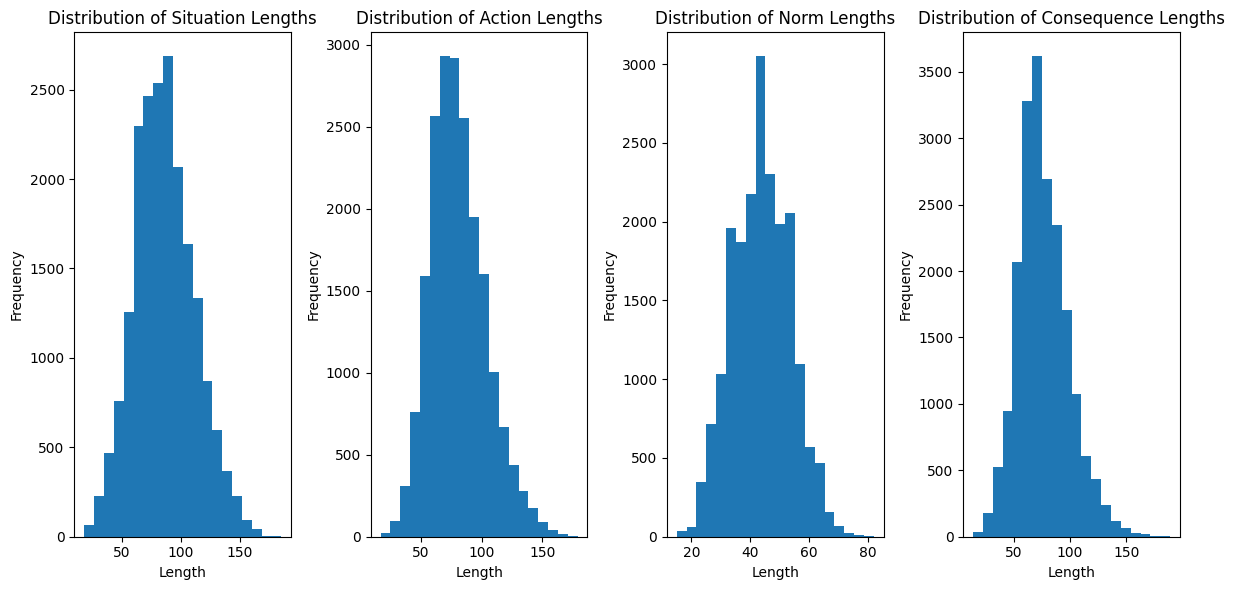

In [ ]:
import matplotlib.pyplot as plt

situation_lengths = [len(text) for text in moral_train_dataset['situation']]
norm_lengths = [len(text) for text in moral_train_dataset['norm']]

moral_action_lengths = []
for action in moral_train_dataset['moral_action']:
  if action != 'not specified':
    moral_action_lengths.append(len(action))
immoral_action_lengths = []
for action in moral_train_dataset['immoral_action']:
  if action != 'not specified':
    immoral_action_lengths.append(len(action))
action_lengths = moral_action_lengths + immoral_action_lengths

moral_consequence_lengths = []
for consequence in moral_train_dataset['moral_consequence']:
  if consequence != 'not specified':
    moral_consequence_lengths.append(len(consequence))
immoral_consequence_lengths = []
for consequence in moral_train_dataset['immoral_consequence']:
  if consequence != 'not specified':
    immoral_consequence_lengths.append(len(consequence))
consequence_lengths = moral_consequence_lengths + immoral_consequence_lengths

plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.hist(situation_lengths, bins=20)
plt.title('Distribution of Situation Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 4, 2)
plt.hist(action_lengths, bins=20)
plt.title('Distribution of Action Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 4, 3)
plt.hist(norm_lengths, bins=20)
plt.title('Distribution of Norm Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 4, 4)
plt.hist(consequence_lengths, bins=20)
plt.title('Distribution of Consequence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

print(f"The mean of situation_lengths is: {np.mean(situation_lengths)}")
print(f"The mean of moral_action_lengths (excluding 0) is: {np.mean(moral_action_lengths)}")
print(f"The mean of immoral_action_lengths (excluding 0) is: {np.mean(immoral_action_lengths)}")
print(f"The mean of norm_lengths is: {np.mean(norm_lengths)}")
print(f"The mean of moral_consequence_lengths (excluding 0) is: {np.mean(moral_consequence_lengths)}")
print(f"The mean of immoral_consequence_lengths (excluding 0) is: {np.mean(immoral_consequence_lengths)}")


The mean of situation_lengths is: 85.9598
The mean of moral_action_lengths (excluding 0) is: 80.656
The mean of immoral_action_lengths (excluding 0) is: 80.8544
The mean of norm_lengths is: 43.8687
The mean of moral_consequence_lengths (excluding 0) is: 75.575
The mean of immoral_consequence_lengths (excluding 0) is: 77.0968


In [ ]:
MAX_SEQUENCE_LENGTH = 128

## 0.3. Data Preparation

In [ ]:
def preprocess_moral(data, tokenizer):
    merged_texts = []

    for moral, immoral in zip(data['moral_action'], data['immoral_action']):
        # Ignore "not specified" values for moral and immoral actions
        if moral.lower() == "not specified":
            action_text = immoral
        elif immoral.lower() == "not specified":
            action_text = moral
        else:
            action_text = f"{moral} {immoral}"  # Merge both sentences

        # Add the [CLS] token at the beginning, followed by situation, norm, and action_text, all separated by [SEP]
        #action_text = f"[CLS] {action_text} [SEP]"

        merged_texts.append(action_text)  # Store the merged text

    # Tokenize the batch of merged sentences
    encoded = tokenizer.batch_encode_plus(
        merged_texts,
        max_length=MAX_SEQUENCE_LENGTH,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )

    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "token_type_ids": encoded["token_type_ids"]
    }


In [ ]:
MAX_SEQUENCE_LENGTH = 128

In [ ]:

# Load accuracy and F1 metrics
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)  # Convert logits to class predictions

    # Compute accuracy
    acc = metric_acc.compute(predictions=predictions, references=labels)

    # Compute F1-score (weighted to account for class imbalance)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="weighted")

    # Return both metrics
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}


In [ ]:
from transformers import Trainer, TrainingArguments

def fine_tune_classification_model(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "token_type_ids": example["token_type_ids"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }


    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=2e-5,
        logging_dir="./logs",
        logging_steps=200
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()


## Model Training

In [ ]:
"""
Show the output from training roberta-large on the Moral reviews dataset.
"""

# Use RoBERTa-large
model_checkpoint_name = "roberta-large"

# Load RoBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.406700,0.400037,0.832500


Epoch,Training Loss,Validation Loss,Accuracy
1,0.406700,0.400037,0.832500
2,0.306400,0.461901,0.841500
3,0.191400,0.587872,0.847000


## Partial Fine Tuning

In [ ]:
model_checkpoint_name = "roberta-large"
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

for param in classification_model.roberta.parameters():
    param.requires_grad = False

for param in classification_model.roberta.encoder.layer[-3:].parameters():
    param.requires_grad = True  # Unfreeze the last 3 layers

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: statmathcat (statmathcat-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.442100,0.457347,0.794500,0.793226
2,0.386600,0.432451,0.814000,0.813785
3,0.358200,0.452216,0.811500,0.810979


In [ ]:
model_checkpoint_name = "roberta-large"
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

for param in classification_model.roberta.parameters():
    param.requires_grad = False

for param in classification_model.roberta.encoder.layer[-6:].parameters():
    param.requires_grad = True  # Unfreeze the last 6 layers

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)

fine_tune_classification_model(
    classification_model,
    tokenizer,
    moral_train_dataset,
    moral_dev_dataset,
    num_epochs=3  # As used in the paper
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

...

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: statmathcat (statmathcat-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.415500,0.416926,0.815500,0.815490
2,0.348800,0.415273,0.833000,0.832887
3,0.294800,0.436516,0.836000,0.835763


In [ ]:
def fine_tune_classification_model2(classification_model,
                                   tokenizer,
                                   train_data,
                                   dev_data,
                                   batch_size=16,
                                   num_epochs=2,
                                   learning_rate=2e-5):
    """
    Preprocess the data using the given tokenizer (now merging moral_action and immoral_action).
    Create the training arguments and trainer for the given model and data.
    Then train it.
    """

    # Preprocess train and dev data, handling batched input correctly
    preprocessed_train_data = train_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})
    preprocessed_dev_data = dev_data.map(preprocess_moral, batched=True, fn_kwargs={'tokenizer': tokenizer})

    # Format dataset to match model input expectations
    def format_dataset(example):
        return {
            "input_ids": example["input_ids"],
            "attention_mask": example["attention_mask"],
            "token_type_ids": example["token_type_ids"],
            "labels": example["label"] if "label" in example else 0  # Default to 0 if missing
        }


    formatted_train_data = preprocessed_train_data.map(format_dataset, remove_columns=preprocessed_train_data.column_names)
    formatted_dev_data = preprocessed_dev_data.map(format_dataset, remove_columns=preprocessed_dev_data.column_names)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.05,
        learning_rate=learning_rate,
        logging_dir="./logs",
        logging_steps=200
    )

    # Create Trainer instance
    trainer = Trainer(
        model=classification_model,
        args=training_args,
        train_dataset=formatted_train_data,
        eval_dataset=formatted_dev_data,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()

In [ ]:
learning_rates = [1e-5, 5e-5, 1e-4]

for lr in learning_rates:
    print(f"Training with learning rate: {lr}")

    model_checkpoint_name = "roberta-large"
    classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

    for param in classification_model.roberta.parameters():
        param.requires_grad = False

    for param in classification_model.roberta.encoder.layer[-6:].parameters():
        param.requires_grad = True  # Unfreeze the last 6 layers

    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint_name)

    fine_tune_classification_model2(
        classification_model,
        tokenizer,
        moral_train_dataset,
        moral_dev_dataset,
        num_epochs=3,  # As used in the paper
    )

Training with learning rate: 1e-05


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

...

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.418700,0.411481,0.813000,0.812744
2,0.334700,0.492111,0.814500,0.812372
3,0.304300,0.440052,0.827500,0.827217


Training with learning rate: 0.0001


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.418700,0.411481,0.813000,0.812744
2,0.334700,0.492111,0.814500,0.812372
3,0.304300,0.440052,0.827500,0.827217


In [ ]:
model_checkpoint_name = "roberta-large"
classification_model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint_name)

for name, param in classification_model.named_parameters():
    print(name, param.requires_grad)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


roberta.embeddings.word_embeddings.weight True
roberta.embeddings.position_embeddings.weight True
roberta.embeddings.token_type_embeddings.weight True
roberta.embeddings.LayerNorm.weight True
roberta.embeddings.LayerNorm.bias True
roberta.encoder.layer.0.attention.self.query.weight True
roberta.encoder.layer.0.attention.self.query.bias True
roberta.encoder.layer.0.attention.self.key.weight True
roberta.encoder.layer.0.attention.self.key.bias True
roberta.encoder.layer.0.attention.self.value.weight True
roberta.encoder.layer.0.attention.self.value.bias True
roberta.encoder.layer.0.attention.output.dense.weight True
roberta.encoder.layer.0.attention.output.dense.bias True
roberta.encoder.layer.0.attention.output.LayerNorm.weight True
roberta.encoder.layer.0.attention.output.LayerNorm.bias True
roberta.encoder.layer.0.intermediate.dense.weight True
roberta.encoder.layer.0.intermediate.dense.bias True
roberta.encoder.layer.0.output.dense.weight True
roberta.encoder.layer.0.output.dense.bia